# Life Expectancy Prediction Using Linear Regression, Decision Trees & Random Forest

## Use Case
Predicting the **life expectancy** of populations across countries using socio-economic and health-related indicators. This model can help public-health organizations and NGOs **prioritize interventions** (e.g. immunization campaigns, schooling investment, HIV/AIDS programs) in countries where life expectancy is projected to be lowest.

## Dataset
- **Source:** WHO Life Expectancy Dataset (Kaggle)  
- **Link:** https://www.kaggle.com/datasets/vikramamin/life-expectancy-who/ 
- **Records:** 2,938 rows | 22 columns  
- **Period:** 2000–2015 | 193 countries  

The dataset combines data from the WHO Global Health Observatory and the United Nations, covering immunization, mortality, economic, and social factors that influence life expectancy.

**Target Variable:** `Life expectancy` (continuous, in years)

## 1. Imports & Setup

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

## 2. Load & Explore the Data

In [5]:
df = pd.read_csv('Life Expectancy Data.csv')
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
df.head()

Shape: (2938, 22)

Column types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
df.describe().round(2)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70


In [7]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

,Missing,Percent
Population,652,22.19
Hepatitis B,553,18.82
GDP,448,15.25
Total expenditure,226,7.69
Alcohol,194,6.60
Income composition of resources,167,5.68
Schooling,163,5.55
BMI,34,1.16
thinness 1-19 years,34,1.16
thinness 5-9 years,34,1.16


## 3. Data Cleaning & Feature Engineering

In [8]:
# 3a. Drop rows where the target is missing
df.dropna(subset=['Life expectancy'], inplace=True)

# 3b. Drop 'Country' – high-cardinality nominal feature not useful
#      for a simple regression pipeline without target encoding
df.drop(columns=['Country'], inplace=True)

# 3c. Convert categorical 'Status' to numeric
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])   # Developed=0, Developing=1
print('Encoded Status: Developed -> 0, Developing -> 1')

# 3d. Impute remaining missing values with column medians
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f'Remaining missing values: {df.isnull().sum().sum()}')

Encoded Status: Developed -> 0, Developing -> 1
Remaining missing values: 0


### Feature Engineering Interpretation

**Columns KEPT and rationale:**

| Feature | Rationale |
|---|---|
| Year | Temporal trend in global health improvement |
| Status | Binary flag (Developed / Developing) encodes wealth level |
| Adult Mortality | Strong inverse relationship with life expectancy |
| infant deaths | Child mortality is a key public-health indicator |
| Alcohol | Lifestyle factor linked to chronic disease |
| percentage expenditure | Health expenditure as % of GDP |
| Hepatitis B | Immunization coverage proxy |
| Measles | Disease burden indicator |
| BMI | Population nutrition status |
| under-five deaths | Captures wider child mortality |
| Polio, Diphtheria | Immunization coverage |
| Total expenditure | Government health spending share |
| HIV/AIDS | Major mortality driver in sub-Saharan Africa |
| GDP | Economic capacity |
| Population | Country size (controls for scale effects) |
| thinness 1-19 years, thinness 5-9 years | Malnutrition proxies |
| Income composition of resources | HDI income index |
| Schooling | Education level, strong positive predictor |

**Dropped:** `Country` — high-cardinality string not suitable for direct regression. All remaining features have a plausible causal or correlational link to life expectancy.

**Converted to numeric:** `Status` (Developed/Developing → 0/1 via LabelEncoder).

## 4. Visualizations

### 4a. Correlation Heatmap

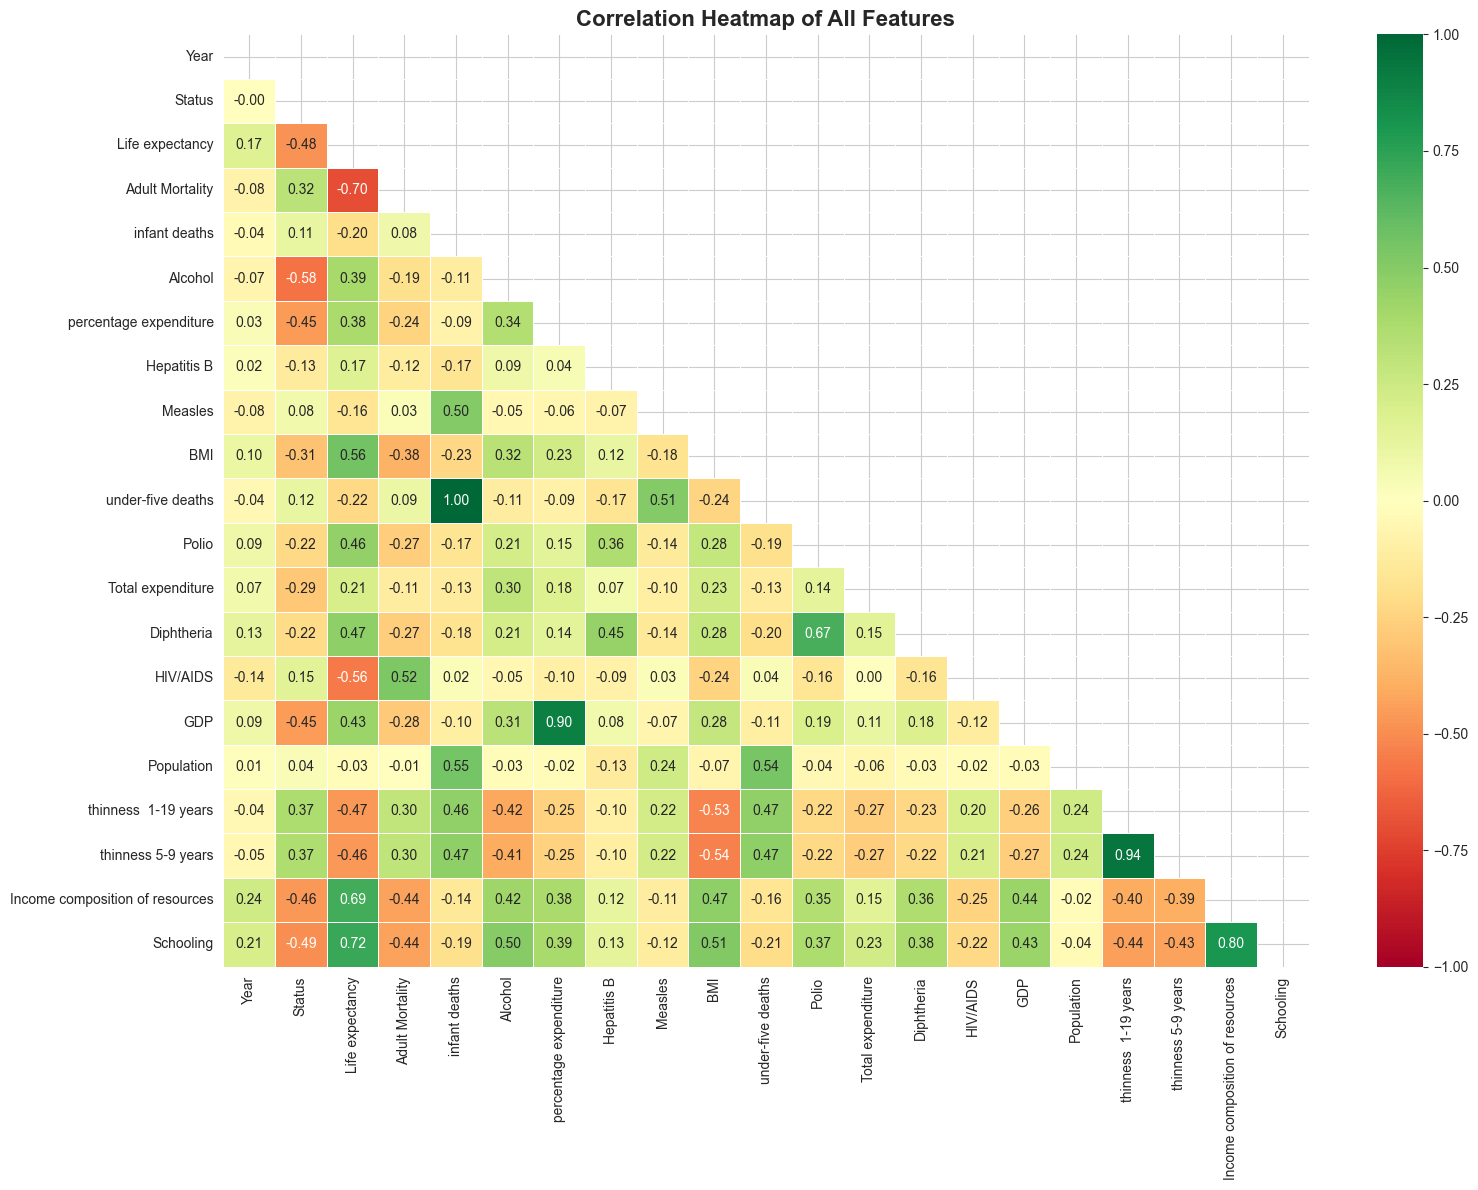

In [9]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of All Features', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**  
- **Schooling (+0.75)** and **Income composition of resources (+0.72)** have the strongest positive correlation with life expectancy.  
- **Adult Mortality (−0.70)** and **HIV/AIDS (−0.56)** show strong negative correlations — countries with high adult mortality or HIV rates have significantly lower life expectancy.  
- **Thinness indicators** are negatively correlated (~−0.47), confirming malnutrition's impact.  
- High multicollinearity between `thinness 1-19 years` and `thinness 5-9 years` (~0.93), and between `infant deaths` and `under-five deaths` (~0.99) — tree-based models handle this well.

### 4b. Target Distribution & Boxplot by Status

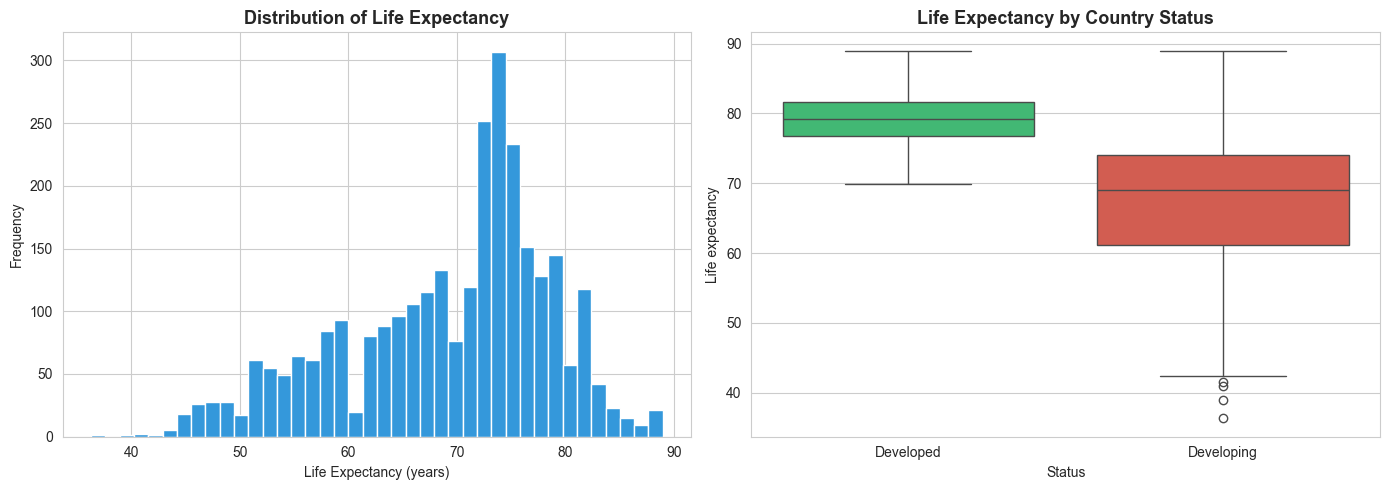

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Life expectancy'], bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution of Life Expectancy', fontsize=13, weight='bold')
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x='Status', y='Life expectancy', data=df, ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Developed', 'Developing'])
axes[1].set_title('Life Expectancy by Country Status', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**  
- Life expectancy is **left-skewed** (peak around 70–75 years).  
- **Developed countries** cluster tightly at 75–85 years; **developing countries** show a much wider spread (40–80 years), indicating far greater variance in health outcomes.

### 4c. Scatter Plots – Top 6 Correlated Features

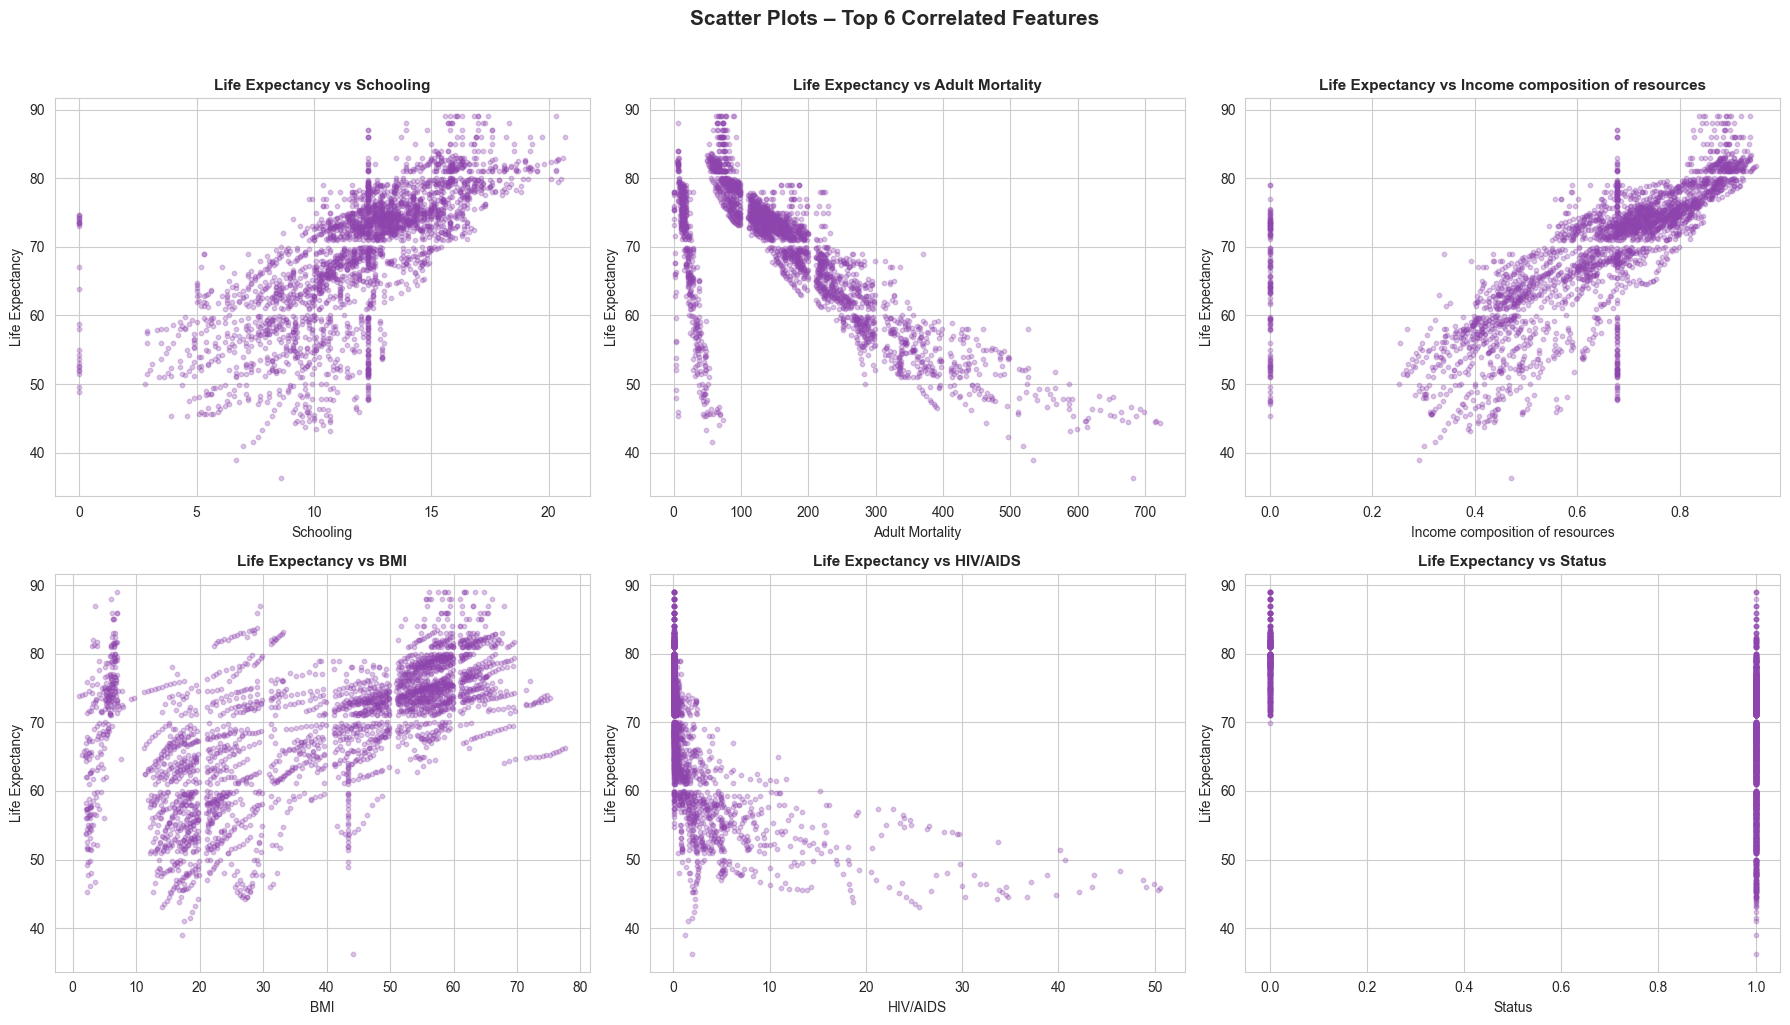

In [11]:
top_features = corr['Life expectancy'].drop('Life expectancy').abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(top_features):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df['Life expectancy'], alpha=0.3, s=10, c='#8e44ad')
    ax.set_xlabel(feat)
    ax.set_ylabel('Life Expectancy')
    ax.set_title(f'Life Expectancy vs {feat}', fontsize=11, weight='bold')
plt.suptitle('Scatter Plots – Top 6 Correlated Features', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**  
- **Schooling** and **Income composition** show clear positive linear trends — ideal for linear regression.  
- **HIV/AIDS** shows an exponential-decay-like pattern — most countries near 0, but a long tail that drags life expectancy down dramatically.  
- **Adult Mortality** has a strong negative linear trend.

### 4d. Feature Distributions (Histograms)

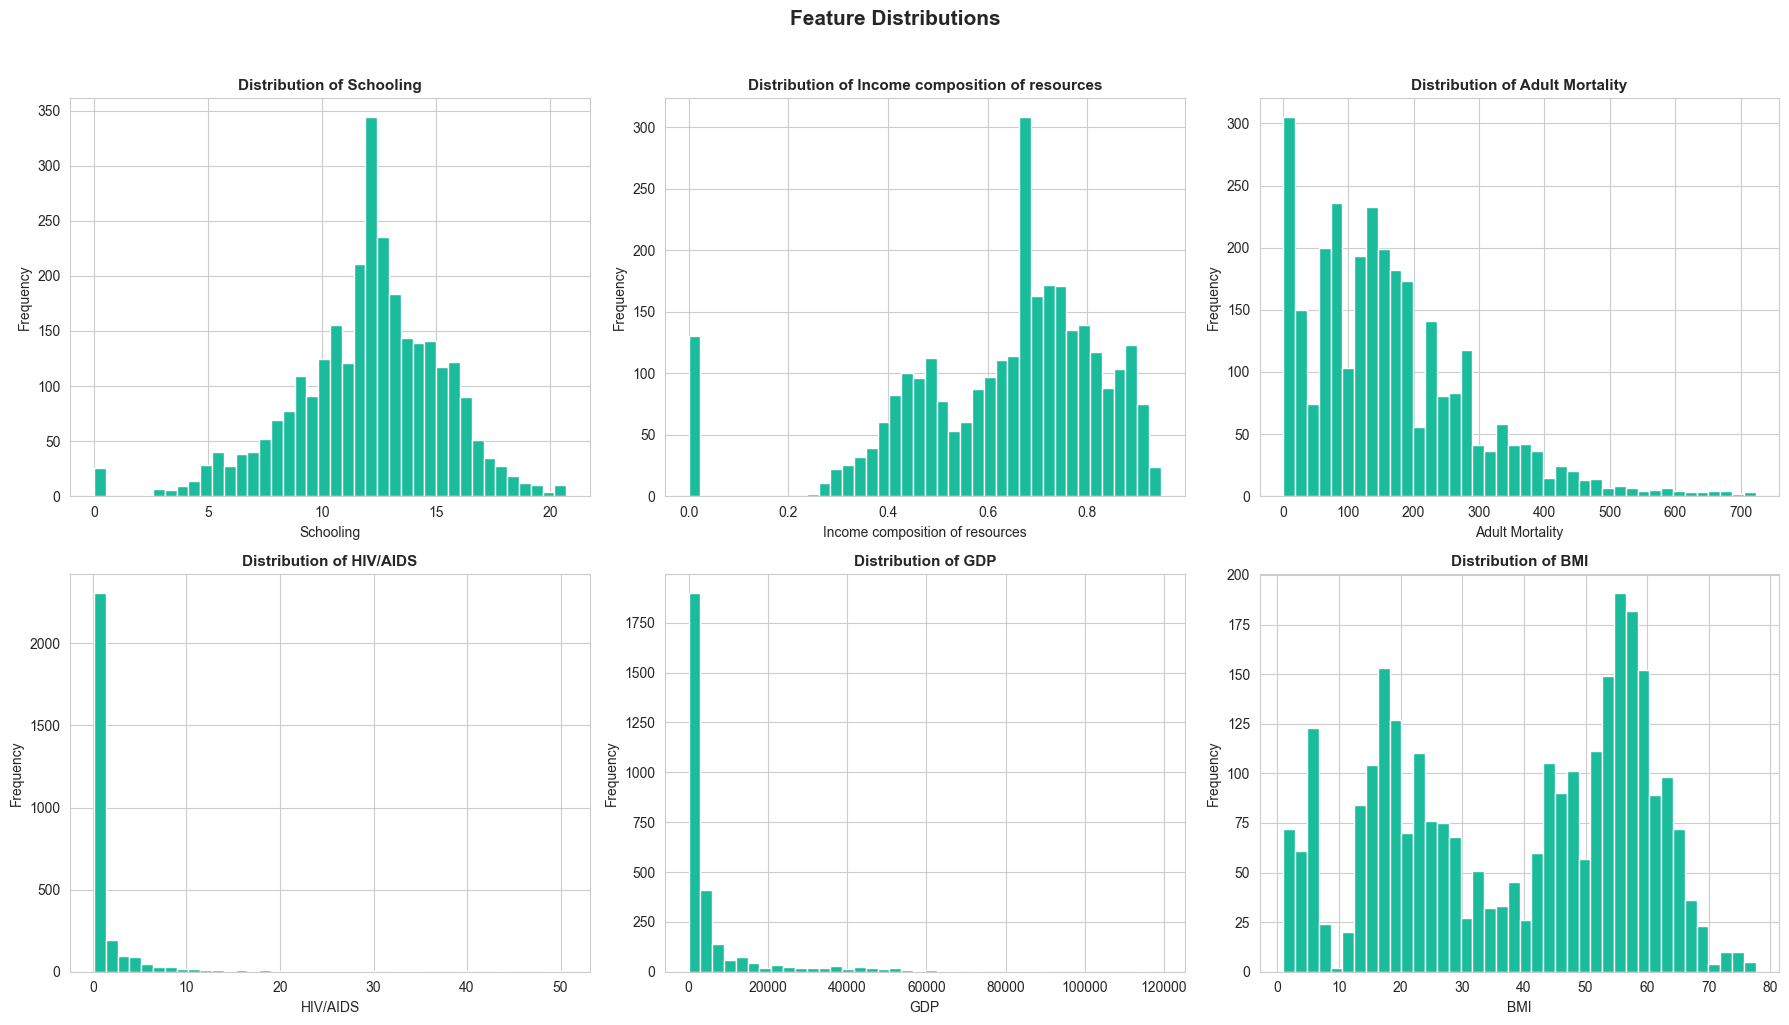

In [12]:
key_feats = ['Schooling', 'Income composition of resources', 'Adult Mortality', 'HIV/AIDS', 'GDP', 'BMI']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(key_feats):
    ax = axes[i // 3][i % 3]
    ax.hist(df[feat].dropna(), bins=40, color='#1abc9c', edgecolor='white')
    ax.set_title(f'Distribution of {feat}', fontsize=11, weight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Train / Test Split & Standardization

In [13]:
X = df.drop(columns=['Life expectancy'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}')
print(f'Features  : {X_train_scaled.shape[1]}')

Train size: 2342  |  Test size: 586
Features  : 20


## 6. Model Training

### 6a. Linear Regression (SGDRegressor – Gradient Descent)

In [14]:
sgd = SGDRegressor(
    loss='squared_error',
    max_iter=1,
    tol=None,
    warm_start=True,
    learning_rate='invscaling',
    eta0=0.001,
    power_t=0.25,
    random_state=42,
    penalty='l2',
    alpha=0.0001
)

n_epochs = 300
train_losses_lr = []
test_losses_lr = []

for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    y_pred_train = sgd.predict(X_train_scaled)
    y_pred_test = sgd.predict(X_test_scaled)
    train_losses_lr.append(mean_squared_error(y_train, y_pred_train))
    test_losses_lr.append(mean_squared_error(y_test, y_pred_test))

y_pred_lr = sgd.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression (SGD) Results:')
print(f'  MSE : {mse_lr:.4f}')
print(f'  MAE : {mae_lr:.4f}')
print(f'  R²  : {r2_lr:.4f}')

Linear Regression (SGD) Results:
  MSE : 16.3427
  MAE : 3.0039
  R²  : 0.8111


### 6b. Decision Tree Regressor

In [15]:
dt = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_leaf=5)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree Results:')
print(f'  MSE : {mse_dt:.4f}')
print(f'  MAE : {mae_dt:.4f}')
print(f'  R²  : {r2_dt:.4f}')

# Loss curve data (varying depth)
train_losses_dt = []
test_losses_dt = []
depth_range = range(1, 31)
for d in depth_range:
    tmp = DecisionTreeRegressor(random_state=42, max_depth=d, min_samples_leaf=5)
    tmp.fit(X_train_scaled, y_train)
    train_losses_dt.append(mean_squared_error(y_train, tmp.predict(X_train_scaled)))
    test_losses_dt.append(mean_squared_error(y_test, tmp.predict(X_test_scaled)))

Decision Tree Results:
  MSE : 5.6207
  MAE : 1.5690
  R²  : 0.9350


### 6c. Random Forest Regressor

In [16]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=3,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest Results:')
print(f'  MSE : {mse_rf:.4f}')
print(f'  MAE : {mae_rf:.4f}')
print(f'  R²  : {r2_rf:.4f}')

# Loss curve data (varying n_estimators)
train_losses_rf = []
test_losses_rf = []
est_range = range(10, 210, 10)
for n in est_range:
    tmp = RandomForestRegressor(n_estimators=n, max_depth=15, min_samples_leaf=3,
                                random_state=42, n_jobs=-1)
    tmp.fit(X_train_scaled, y_train)
    train_losses_rf.append(mean_squared_error(y_train, tmp.predict(X_train_scaled)))
    test_losses_rf.append(mean_squared_error(y_test, tmp.predict(X_test_scaled)))

Random Forest Results:
  MSE : 2.9528
  MAE : 1.0817
  R²  : 0.9659


## 7. Loss Curves (Train & Test)

### 7a. Linear Regression Loss Curve

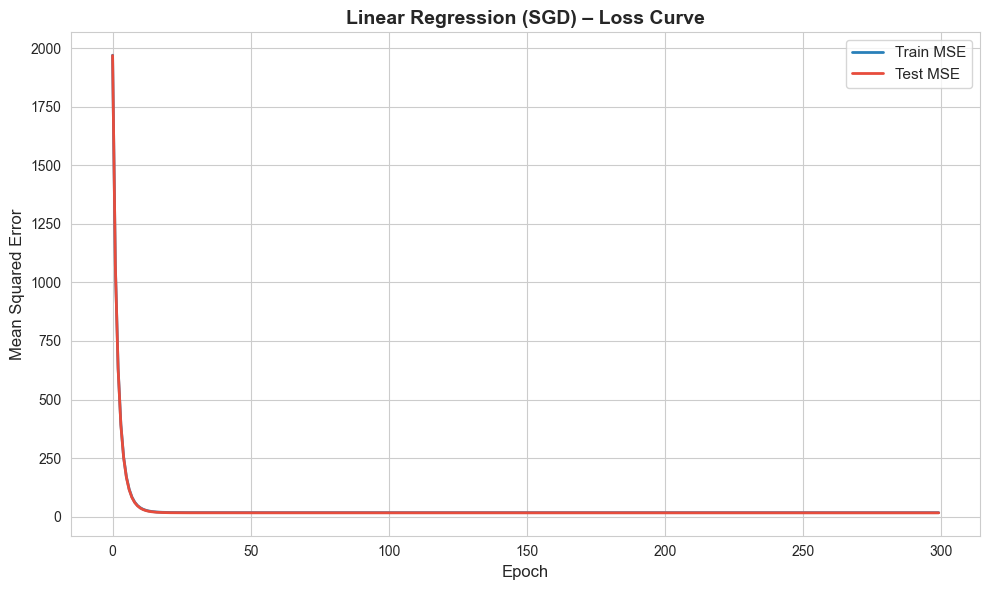

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(n_epochs), train_losses_lr, label='Train MSE', color='#2980b9', linewidth=2)
ax.plot(range(n_epochs), test_losses_lr, label='Test MSE', color='#e74c3c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Linear Regression (SGD) – Loss Curve', fontsize=14, weight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7b. Decision Tree Loss Curve

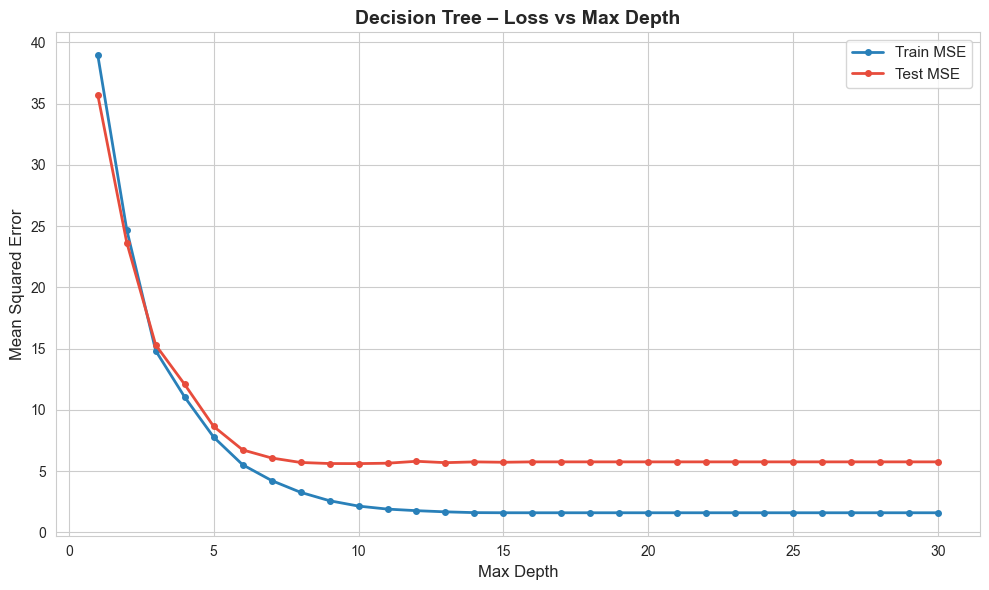

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(depth_range), train_losses_dt, label='Train MSE', color='#2980b9', linewidth=2, marker='o', markersize=4)
ax.plot(list(depth_range), test_losses_dt, label='Test MSE', color='#e74c3c', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Max Depth', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Decision Tree – Loss vs Max Depth', fontsize=14, weight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7c. Random Forest Loss Curve

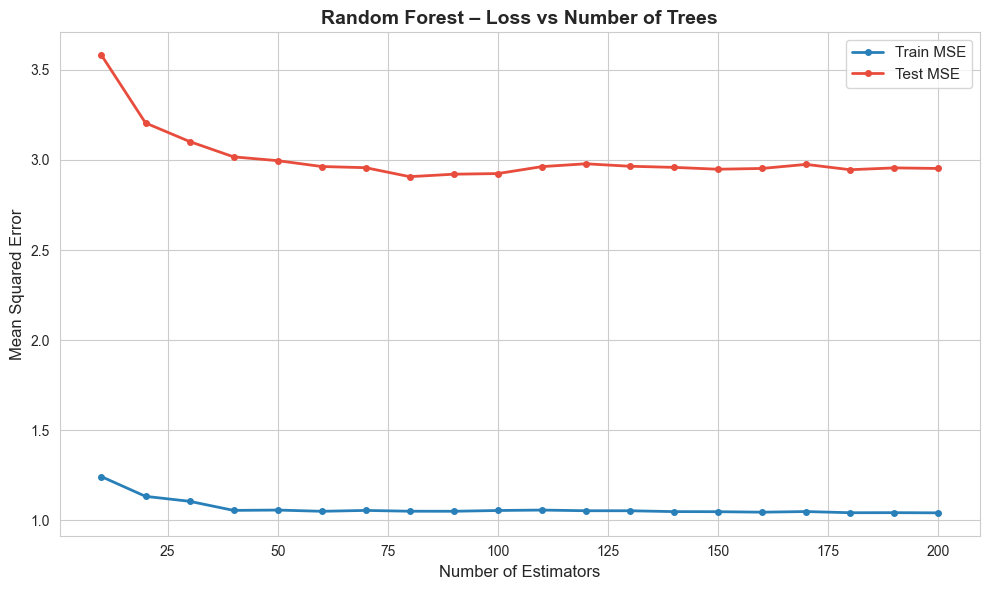

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(est_range), train_losses_rf, label='Train MSE', color='#2980b9', linewidth=2, marker='o', markersize=4)
ax.plot(list(est_range), test_losses_rf, label='Test MSE', color='#e74c3c', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Number of Estimators', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Random Forest – Loss vs Number of Trees', fontsize=14, weight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Scatter Plots – Before & After Training

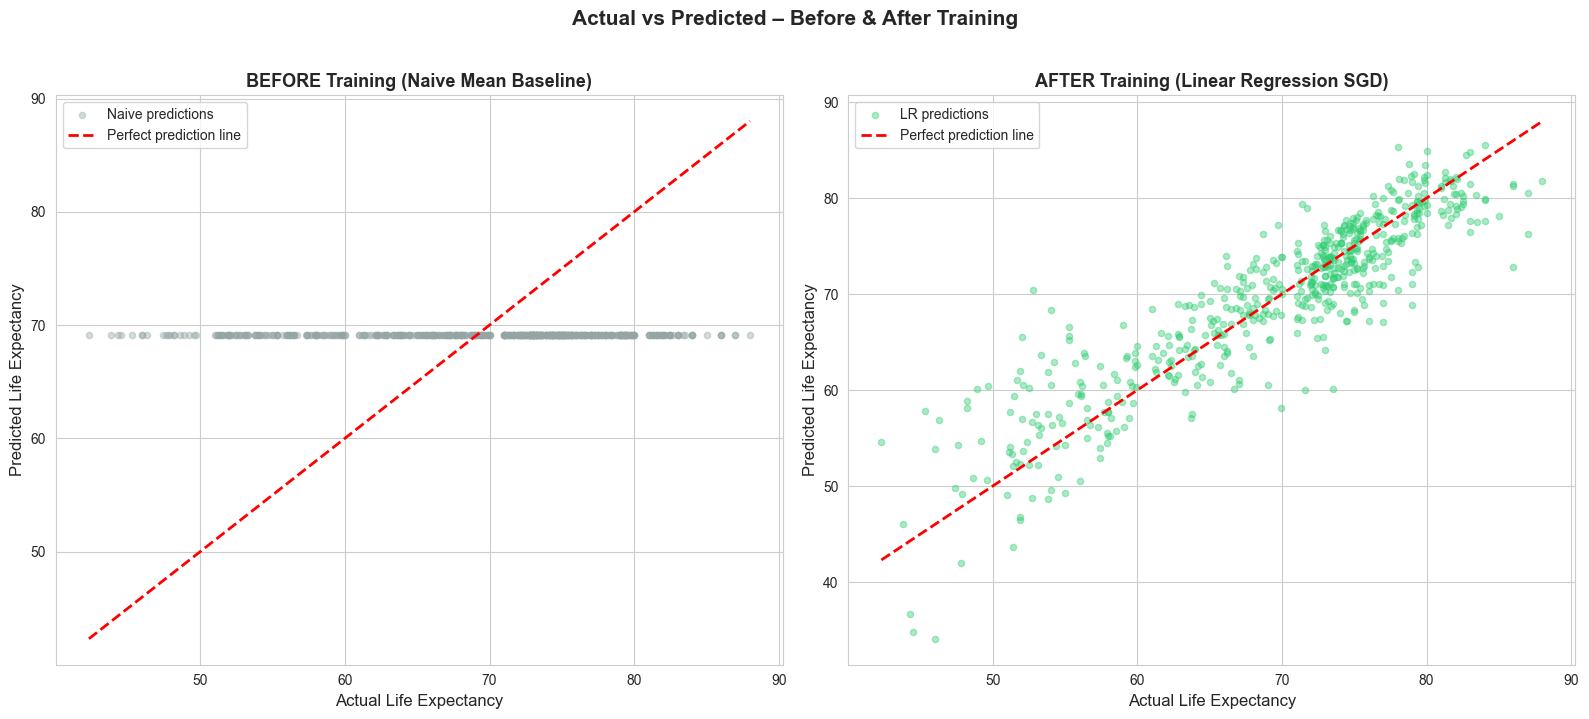

In [20]:
# "Before" = naive baseline (predict the mean for everyone)
y_naive = np.full_like(y_test, y_train.mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Before (naive)
axes[0].scatter(y_test, y_naive, alpha=0.4, s=20, color='#95a5a6', label='Naive predictions')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Life Expectancy', fontsize=12)
axes[0].set_ylabel('Predicted Life Expectancy', fontsize=12)
axes[0].set_title('BEFORE Training (Naive Mean Baseline)', fontsize=13, weight='bold')
axes[0].legend()

# After (Linear Regression)
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, s=20, color='#2ecc71', label='LR predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction line')
axes[1].set_xlabel('Actual Life Expectancy', fontsize=12)
axes[1].set_ylabel('Predicted Life Expectancy', fontsize=12)
axes[1].set_title('AFTER Training (Linear Regression SGD)', fontsize=13, weight='bold')
axes[1].legend()

plt.suptitle('Actual vs Predicted – Before & After Training', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Linear Regression Fit Line (Schooling vs Life Expectancy)

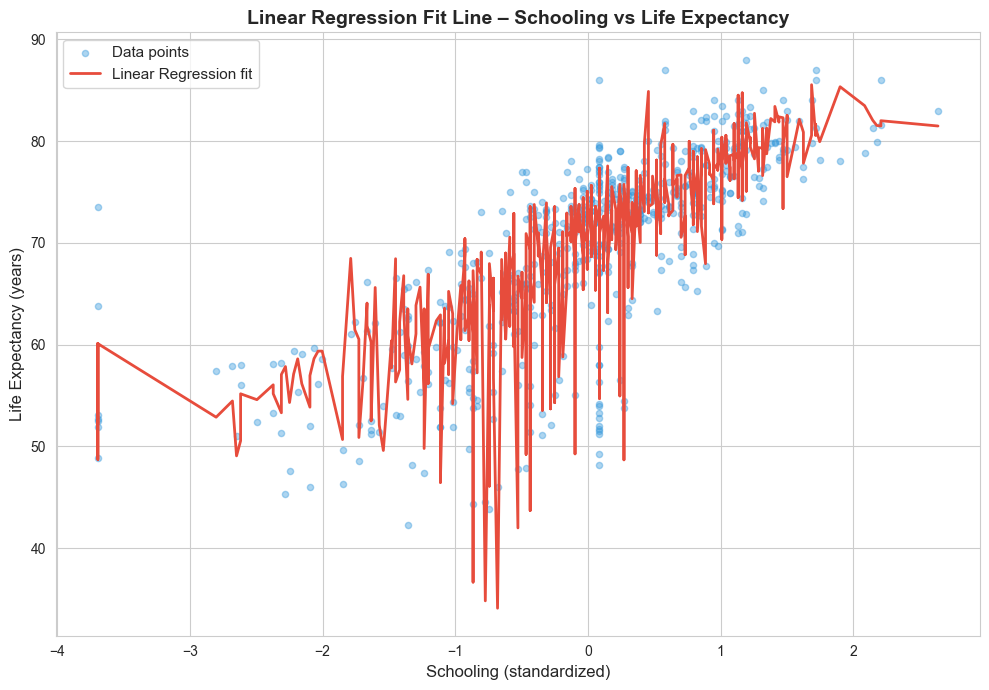

In [21]:
feat_idx = list(X.columns).index('Schooling')

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_test_scaled[:, feat_idx], y_test, alpha=0.4, s=20, color='#3498db', label='Data points')

# Sort for a clean line plot
sort_idx = np.argsort(X_test_scaled[:, feat_idx])
ax.plot(X_test_scaled[:, feat_idx][sort_idx], y_pred_lr[sort_idx],
        color='#e74c3c', linewidth=2, label='Linear Regression fit')
ax.set_xlabel('Schooling (standardized)', fontsize=12)
ax.set_ylabel('Life Expectancy (years)', fontsize=12)
ax.set_title('Linear Regression Fit Line – Schooling vs Life Expectancy',
             fontsize=14, weight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9. Model Comparison & Save Best Model

In [22]:
results = {
    'Linear Regression (SGD)': {'MSE': mse_lr, 'MAE': mae_lr, 'R2': r2_lr},
    'Decision Tree':           {'MSE': mse_dt, 'MAE': mae_dt, 'R2': r2_dt},
    'Random Forest':           {'MSE': mse_rf, 'MAE': mae_rf, 'R2': r2_rf},
}

comp_df = pd.DataFrame(results).T.sort_values('MSE')
print(comp_df.to_string())

best_name = comp_df.index[0]
print(f'\n*** BEST MODEL (lowest MSE): {best_name} ***')

                               MSE       MAE        R2
Random Forest             2.952824  1.081721  0.965863
Decision Tree             5.620665  1.568974  0.935021
Linear Regression (SGD)  16.342741  3.003912  0.811065

*** BEST MODEL (lowest MSE): Random Forest ***


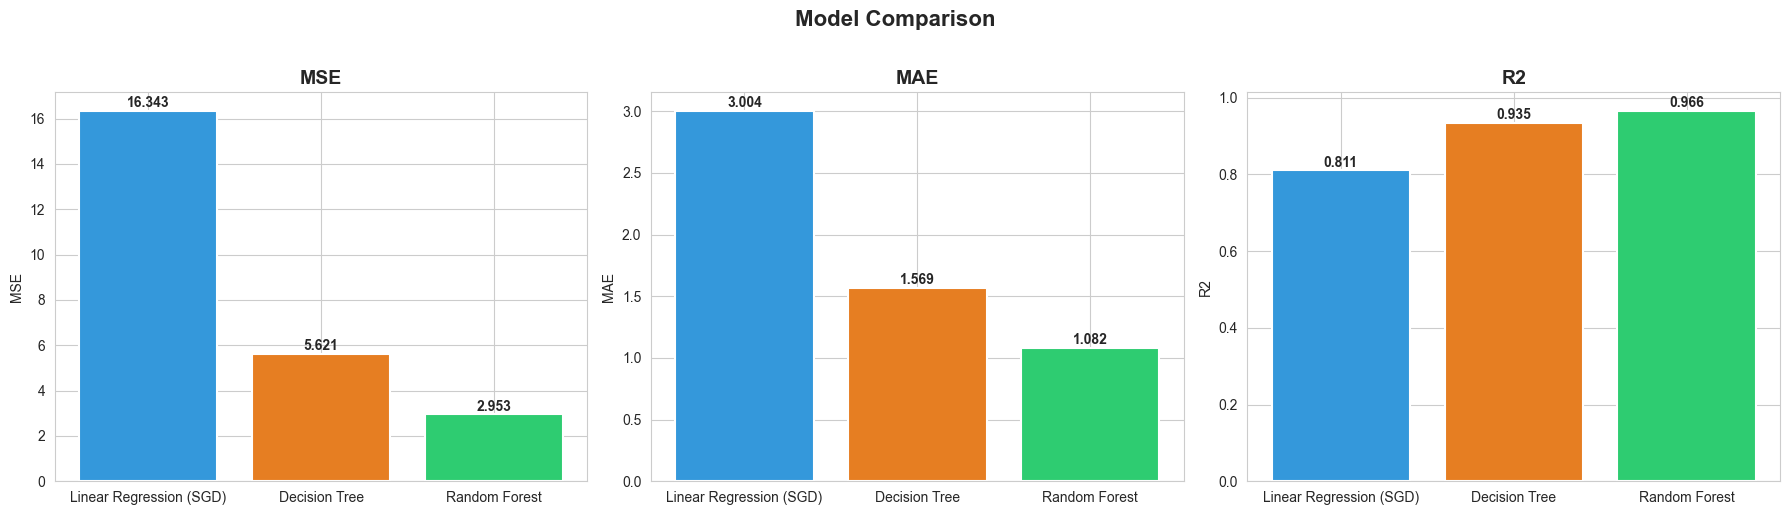

In [23]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = list(results.keys())
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, metric in enumerate(['MSE', 'MAE', 'R2']):
    vals = [results[m][metric] for m in models]
    axes[i].bar(models, vals, color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(metric, fontsize=14, weight='bold')
    axes[i].set_ylabel(metric)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.01 * max(vals), f'{v:.3f}', ha='center', fontsize=10, weight='bold')

plt.suptitle('Model Comparison', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Save the best model
if 'Random Forest' in best_name:
    best_model = rf
elif 'Decision Tree' in best_name:
    best_model = dt
else:
    best_model = sgd

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print(f'Saved: best_model.pkl  ({best_name})')
print(f'Saved: scaler.pkl')
print(f'Saved: feature_names.pkl')

Saved: best_model.pkl  (Random Forest)
Saved: scaler.pkl
Saved: feature_names.pkl


## 10. Single Data-Point Prediction (One Row from Test Set)

In [25]:
sample_idx = 0
sample_X = X_test_scaled[sample_idx].reshape(1, -1)
actual_value = y_test.iloc[sample_idx]
predicted_value = best_model.predict(sample_X)[0]

print('Feature values (original):')
for k, v in X_test.iloc[sample_idx].to_dict().items():
    print(f'  {k:>40s} : {v}')

print(f'\n  Actual Life Expectancy   : {actual_value:.2f} years')
print(f'  Predicted Life Expectancy: {predicted_value:.2f} years')
print(f'  Error                    : {abs(actual_value - predicted_value):.2f} years')

Feature values (original):
                                      Year : 2009.0
                                    Status : 1.0
                           Adult Mortality : 449.0
                             infant deaths : 46.0
                                   Alcohol : 7.6
                    percentage expenditure : 782.5987144
                               Hepatitis B : 74.0
                                   Measles : 5857.0
                                       BMI : 46.4
                         under-five deaths : 70.0
                                     Polio : 75.0
                         Total expenditure : 8.39
                                Diphtheria : 76.0
                                  HIV/AIDS : 19.0
                                       GDP : 5888.6284
                                Population : 5255813.11
                      thinness  1-19 years : 8.1
                        thinness 5-9 years : 9.8
           Income composition of resources : 0.622
   

## 11. Prediction Script

The cell below loads the saved best model and makes a prediction on a new data point. This can be extracted and used as a standalone script.

In [26]:
# ============================================================
#  PREDICTION SCRIPT – Load best model & predict
# ============================================================

import numpy as np
import pandas as pd
import joblib
import warnings

# Load saved artifacts
model = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_names = joblib.load('feature_names.pkl')


def predict_life_expectancy(input_dict: dict) -> float:
    """
    Predict life expectancy given a dictionary of feature values.
    """
    # Create a DataFrame to pass to the scaler to avoid the feature names warning
    features_df = pd.DataFrame([input_dict], columns=feature_names)
    
    # Scale the features
    features_scaled = scaler.transform(features_df)
    
    # Return rounded prediction
    return round(model.predict(features_scaled)[0], 2)


# --- Example prediction ---
sample = {
    'Year': 2014,
    'Status': 1,                             # 1 = Developing
    'Adult Mortality': 180,
    'infant deaths': 25,
    'Alcohol': 3.5,
    'percentage expenditure': 150.0,
    'Hepatitis B': 80,
    'Measles': 300,
    'BMI': 35.0,
    'under-five deaths': 35,
    'Polio': 82,
    'Total expenditure': 5.5,
    'Diphtheria': 82,
    'HIV/AIDS': 1.2,
    'GDP': 2500.0,
    'Population': 15000000,
    'thinness  1-19 years': 6.0,
    'thinness 5-9 years': 6.5,
    'Income composition of resources': 0.55,
    'Schooling': 10.5,
}

predicted = predict_life_expectancy(sample)
print(f'>>> Predicted Life Expectancy: {predicted} years <<<')

>>> Predicted Life Expectancy: 63.58 years <<<
